# 🏦 Modelo de Teoría de Colas para Agencias Bancarias
## Sistema M/M/s → M/G/s | Optimización de Servidores

**Objetivo:** Determinar cuántos auxiliares de operaciones necesita cada agencia
por franja horaria para minimizar el costo total (espera + servidores).

---

### 📚 Marco teórico resumido

En una agencia bancaria tenemos:
- **Clientes** que llegan aleatoriamente (proceso de Poisson con tasa λ)
- **Auxiliares** que atienden (cada uno con tasa μ)
- **Cola** que se forma cuando todos están ocupados

El costo total que queremos minimizar es:
```
CT = Costo servidores ocupados + Costo servidores ociosos + Costo espera del cliente
```

Usamos dos modelos:
1. **M/M/s** → llegadas Poisson, servicios exponenciales, s servidores
2. **M/G/s (Allen-Cunneen)** → igual pero con distribución general de servicio (más realista)

---
## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from math import factorial

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 2 — Carga de datos

Tenemos dos fuentes:
- **df.csv**: demanda por agencia y franja horaria (λ, servidores, costos)
- **dist_agencias.csv**: distribución proporcional de operaciones por hora


In [3]:
# Carga de archivos — ajusta la ruta si es necesario
df   = pd.read_csv('df.csv')
dist = pd.read_csv('dist_agencias.csv')

print('=== df.csv ===')
print(f'Dimensiones: {df.shape}')
print(df.head(10))
print()
print('=== dist_agencias.csv ===')
print(f'Dimensiones: {dist.shape}')
print(dist[['agencia','tipo_ope']].to_string())

=== df.csv ===
Dimensiones: (20, 6)
                                 agencia                 hora  lambda  servidores      Cs      Cq
0  AG.PARQUE DE LAS FLORES LOS GUINDALES  09:00:00 - 09:59:59 50.5000           5 13.6400 27.2900
1  AG.PARQUE DE LAS FLORES LOS GUINDALES  10:00:00 - 10:59:59 60.1200           5 13.6400 27.2900
2  AG.PARQUE DE LAS FLORES LOS GUINDALES  11:00:00 - 11:59:59 58.9000           5 13.6400 27.2900
3  AG.PARQUE DE LAS FLORES LOS GUINDALES  12:00:00 - 12:59:59 43.4800           5 13.6400 27.2900
4  AG.PARQUE DE LAS FLORES LOS GUINDALES  13:00:00 - 13:59:59 35.0000           5 13.6400 27.2900
5  AG.PARQUE DE LAS FLORES LOS GUINDALES  14:00:00 - 14:59:59 31.6400           5 13.6400 27.2900
6  AG.PARQUE DE LAS FLORES LOS GUINDALES  15:00:00 - 15:59:59 44.2300           5 13.6400 27.2900
7  AG.PARQUE DE LAS FLORES LOS GUINDALES  16:00:00 - 16:59:59 59.1100           5 13.6400 27.2900
8  AG.PARQUE DE LAS FLORES LOS GUINDALES  17:00:00 - 17:59:59 65.2800           5 

In [4]:
dist['tipo_ope'] = dist['tipo_ope'].replace({
    'COBRANZA LOCALES OTRAS AGENCIAS': 'COBRANZAS'
})

dist = (
    dist
    .groupby(['agencia', 'tipo_ope'], as_index=False)
    
    .sum()
)

dist

,agencia,tipo_ope,09:00:00 - 09:59:59,10:00:00 - 10:59:59,11:00:00 - 11:59:59,12:00:00 - 12:59:59,13:00:00 - 13:59:59,14:00:00 - 14:59:59,15:00:00 - 15:59:59,16:00:00 - 16:59:59,17:00:00 - 17:59:59,18:00:00 - 18:59:59
0,AG. CIUDAD UNIVERSITARIA,APERTURA,0.0388,0.0372,0.0439,0.0446,0.0497,0.0504,0.0428,0.0431,0.0362,0.0727
1,AG. CIUDAD UNIVERSITARIA,COBRANZAS,0.2554,0.2492,0.2469,0.2481,0.2652,0.2651,0.2742,0.2982,0.3175,0.2976
2,AG. CIUDAD UNIVERSITARIA,DEPOSITO,0.4180,0.4114,0.4165,0.4278,0.4257,0.4599,0.4308,0.3692,0.3058,0.2372
3,AG. CIUDAD UNIVERSITARIA,DESEMBOLSO,0.0296,0.0350,0.0374,0.0431,0.0473,0.0403,0.0341,0.0413,0.0684,0.1150
4,AG. CIUDAD UNIVERSITARIA,RETIRO,0.1809,0.1619,0.1583,0.1593,0.1902,0.1615,0.1546,0.1438,0.1265,0.1675
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,APERTURA,0.0375,0.0381,0.0369,0.0459,0.0535,0.0453,0.0462,0.0376,0.0373,0.0662
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZAS,0.4110,0.3715,0.3617,0.3702,0.4558,0.4244,0.3823,0.3629,0.3479,0.3820
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,DEPOSITO,0.3560,0.3570,0.3569,0.3581,0.3474,0.3670,0.3881,0.3595,0.3048,0.2337
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,DESEMBOLSO,0.0289,0.0353,0.0385,0.0454,0.0439,0.0418,0.0314,0.0377,0.0609,0.1220
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,RETIRO,0.0941,0.0952,0.0995,0.0970,0.0924,0.0875,0.0875,0.1053,0.1253,0.1588


---
## 3 — Tiempos de servicio por tipo de operación

Estos valores representan el **tiempo promedio** (en minutos) y la **varianza** que tarda
cada tipo de operación. Los usaremos para calcular μ ponderado por hora.

**¿Por qué la varianza importa?**
Porque en el mundo real las operaciones no tardan exactamente lo mismo siempre.
Un desembolso puede tardar 5 min o 10 min según el cliente.
Esa variabilidad aumenta las colas aunque la demanda promedio sea igual.
Esto lo captura el modelo M/G/s mediante el coeficiente de variación **C_s²**.

In [5]:
# Tiempo promedio de servicio por tipo de operación (minutos)
T_SERVICIO = {
    'DEPOSITO':                         3.8,
    # 'COBRANZA LOCALES OTRAS AGENCIAS':  2.5,
    'COBRANZAS':                        3.5,
    'RETIRO':                           3.0,
    'DESEMBOLSO':                       20.5,
    'APERTURA':                        12.0
}

# Varianza del tiempo de servicio (minutos²)
# Operaciones simples → baja varianza | complejas → alta varianza
VAR_SERVICIO = {
    'DEPOSITO':                         1.0,
    # 'COBRANZA LOCALES OTRAS AGENCIAS':  3.5,
    'COBRANZAS':                        1.5,
    'RETIRO':                           1.5,
    'DESEMBOLSO':                      7.0,
    'APERTURA':                        5.0
}

dist['t_s'] = dist['tipo_ope'].map(T_SERVICIO)
dist['var_s'] = dist['tipo_ope'].map(VAR_SERVICIO)

print('Parámetros de servicio asignados:')
print(dist[['agencia', 'tipo_ope', 't_s', 'var_s']].drop_duplicates('tipo_ope').to_string(index=False))

Parámetros de servicio asignados:
                 agencia   tipo_ope     t_s  var_s
AG. CIUDAD UNIVERSITARIA   APERTURA 12.0000 5.0000
AG. CIUDAD UNIVERSITARIA  COBRANZAS  3.5000 1.5000
AG. CIUDAD UNIVERSITARIA   DEPOSITO  3.8000 1.0000
AG. CIUDAD UNIVERSITARIA DESEMBOLSO 20.5000 7.0000
AG. CIUDAD UNIVERSITARIA     RETIRO  3.0000 1.5000


---
## 4 — Análisis Exploratorio de Datos (EDA)

Exploramos los datos para entender:
- ¿Cuándo hay más demanda (λ)?
- ¿Los servidores actuales son suficientes?
- ¿Hay horas críticas evidentes?

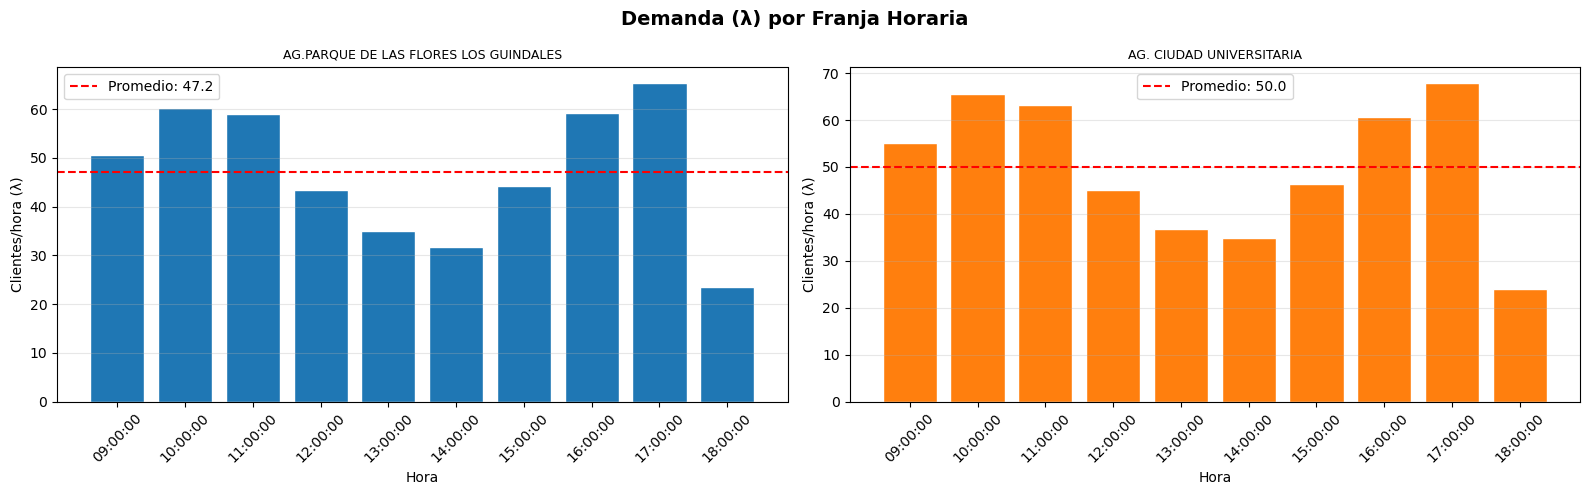

In [6]:
cols_horas = [c for c in dist.columns if ':' in c]
agencias   = df['agencia'].unique()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demanda (λ) por Franja Horaria', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, ['#1f77b4','#ff7f0e']):
    sub = df[df['agencia'] == agencia].copy()
    horas_cortas = [h.split(' ')[0] for h in sub['hora']]
    ax.bar(horas_cortas, sub['lambda'], color=color, edgecolor='white')
    ax.axhline(sub['lambda'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f"Promedio: {sub['lambda'].mean():.1f}")
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_xlabel('Hora')
    ax.set_ylabel('Clientes/hora (λ)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_demanda.png', dpi=120, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_demanda.png')


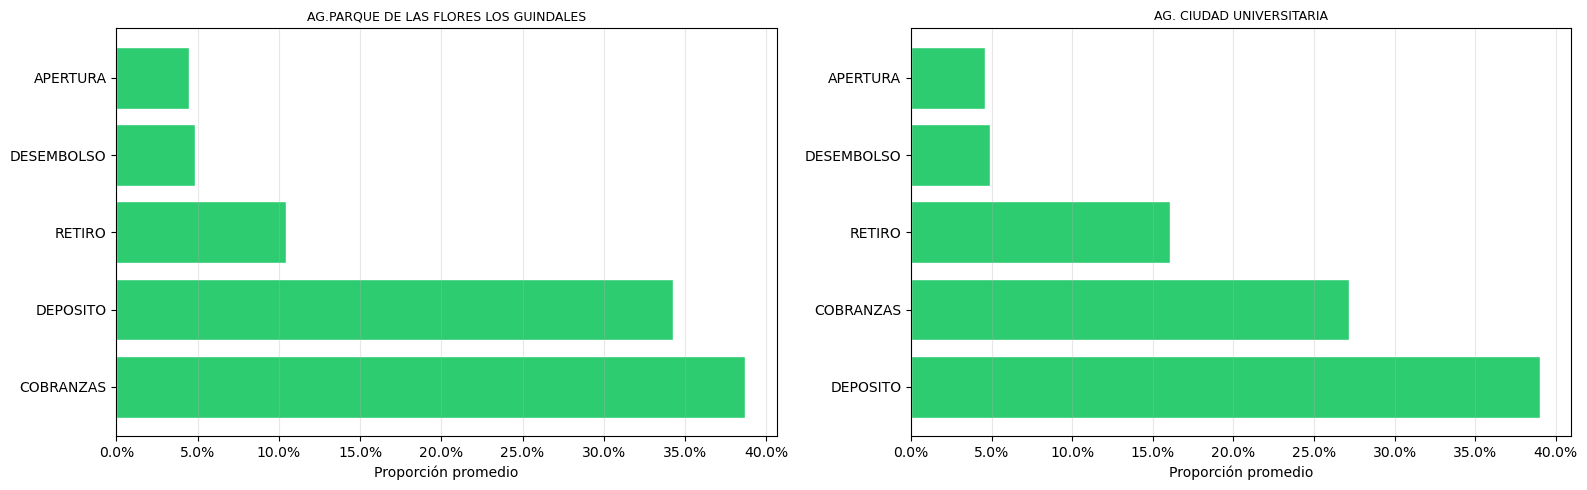

In [7]:
fig, axes = plt.subplots(1,2, figsize=(16,5))


for ax, agencia in zip(axes, agencias):
    sub = dist[dist['agencia'] == agencia].copy()
    sub['prop_media'] = sub[cols_horas].mean(axis=1)
    sub = sub.sort_values(by='prop_media', ascending=False)
    ax.barh(sub['tipo_ope'], sub['prop_media'], color='#2ecc71', edgecolor='white')
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_xlabel('Proporción promedio')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_operaciones.png', dpi=120, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_operaciones.png')

---
## 5 — Cálculo de μ (tasa de servicio) y C_s² ponderados

### ¿Qué es μ?
μ es cuántos clientes puede atender **un solo auxiliar** en una hora.
Como la mezcla de operaciones cambia cada hora, μ también cambia.

**Fórmulas:**
```
E(T)  = Σ [ p_k(hora) × t_k ]          ← tiempo promedio ponderado (minutos)
μ     = 60 / E(T)                        ← clientes por hora
E(T²) = Σ [ p_k × (Var_k + t_k²) ]     ← ley de expectativas totales
Var(T)= E(T²) - [E(T)]²
C_s²  = Var(T) / [E(T)]²                ← coeficiente de variación al cuadrado
```

**Interpretación de C_s²:**
- C_s² = 1 → distribución exponencial (M/M/s exacto)
- C_s² < 1 → tiempos más regulares → colas menores ✅
- C_s² > 1 → tiempos más variables → colas mayores ⚠️

In [8]:
def calcular_mu_C_s2(df_base, dist_df, cols_horas):
    """
    Para cada fila (agencia + hora) calcula mu y C_s².
    
    E[T] es el tiempo promedio ponderado por la mezcla de operaciones.
    C_s² captura la variabilidad de los tiempos de servicio.
    """
    rows = []
    for _, row in df_base.iterrows():
        agencia = row['agencia']
        hora    = row['hora']
        d       = dist_df[dist_df['agencia'] == agencia]
        probs   = d[hora].values.astype(float)
        ts      = d['t_s'].values.astype(float)
        var_s   = d['var_s'].values.astype(float)
        total_p = probs.sum()
        
        if total_p == 0 or np.isnan(total_p):
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan})
            continue
        
        E_T   = np.dot(probs, ts) / total_p
        E_T2  = np.dot(probs, var_s + ts**2) / total_p
        Var_T = E_T2 - E_T**2
        C_s2  = Var_T / E_T**2 if E_T > 0 else np.nan
        mu    = 60.0 / E_T   if E_T > 0 else np.nan
        rows.append({'agencia': agencia, 'hora': hora, 'mu': mu, 'C_s2': C_s2})
    
    return pd.DataFrame(rows)


mu_df = calcular_mu_C_s2(df, dist, cols_horas)

df2   = df.merge(mu_df, on=['agencia','hora'], how='left')

print('μ y C_s² calculados por agencia-hora:')
print(df2[['agencia','hora','lambda','servidores','mu','C_s2']].to_string(index=False))

μ y C_s² calculados por agencia-hora:
                              agencia                hora  lambda  servidores      mu   C_s2
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 13.5202 0.6463
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.0541 0.7085
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 12.9096 0.7344
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 12.4173 0.7698
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 12.5840 0.7422
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 12.7581 0.7332
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 13.1346 0.6632
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 12.9735 0.7270
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2800           5 11.8197 0.8771
AG.PARQUE DE LAS FLORES LOS GUIN

---
## 6 — Modelo M/M/s

### Fórmulas del modelo M/M/s

**ρ (utilización):**  ρ = λ / (s × μ)    debe ser < 1

**P₀ (prob. sistema vacío):**
```
P₀ = 1 / [ Σ(k=0..s-1)(r^k/k!) + r^s/(s!×(1−ρ)) ]   donde r = λ/μ
```

**Lq (clientes en cola):**
```
Lq = P₀ × r^s × ρ / (s! × (1−ρ)²)
```

**Tiempos:**   Wq = Lq/λ  |  Ws = Wq + 1/μ  |  Ls = λ×Ws

**Costos:**
```
CTS      = (Cs + Cq) × (Ls - Lq)     ← servidores ocupados
CTS_idle = Cs × (s - (Ls - Lq))      ← servidores ociosos
CTQ      = λ × Cq × Wq               ← costo de espera
CT       = CTS + CTS_idle + CTQ       ← COSTO TOTAL
```

In [13]:
def mms_metricas(lam, mu, c, Cs, Cq):
    """
    Calcula las 14 métricas del modelo M/M/s.
    Devuelve dict con NaN si el sistema es inválido o inestable (rho >= 1).
    """
    nan_r = dict(rho=np.nan,P0=np.nan,Lq=np.nan,Wq_h=np.nan,Ws_h=np.nan,
                 Ls=np.nan,Wq_m=np.nan,Ws_m=np.nan,serv_ocupados=np.nan,
                 serv_ociosos=np.nan,CTS=np.nan,CTS_idle=np.nan,CTQ=np.nan,CT=np.nan)
    
    if mu <= 0 or c <= 0 or lam < 0:
        return nan_r
    
    c   = int(c)
    rho = lam / (c * mu)
    r   = lam / mu
    
    if rho >= 1:
        return {**nan_r, 'rho': rho}  # sistema inestable
    
    # P0: probabilidad de sistema vacío
    sum_k  = sum(r**k / factorial(k) for k in range(c))
    term_c = (r**c) / (factorial(c) * (1 - rho))
    P0     = 1.0 / (sum_k + term_c)
    
    # Cola
    Lq   = P0 * (r**c) * rho / (factorial(c) * (1 - rho)**2)
    Wq_h = Lq / lam
    Ws_h = Wq_h + 1.0/mu
    Ls   = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60
    
    # Servidores
    serv_ocupados = Ls - Lq
    serv_ociosos  = c - serv_ocupados
    
    # Costos
    CTS      = (Cs + Cq) * serv_ocupados
    CTS_idle = Cs * serv_ociosos
    CTQ      = lam * Cq * Wq_h
    CT       = CTS + CTS_idle + CTQ
    
    return dict(rho=rho,P0=P0,Lq=Lq,Wq_h=Wq_h,Ws_h=Ws_h,Ls=Ls,
                Wq_m=Wq_m,Ws_m=Ws_m,serv_ocupados=serv_ocupados,
                serv_ociosos=serv_ociosos,CTS=CTS,CTS_idle=CTS_idle,CTQ=CTQ,CT=CT)

# Prueba
fila = df2.iloc[0]
res  = mms_metricas(fila['lambda'],fila['mu'],fila['servidores'],fila['Cs'],fila['Cq'])
print(f'=== Prueba M/M/s ===')
print(f'Agencia : {fila["agencia"]}')
print(f'Hora    : {fila["hora"]}')
print(f'λ={fila["lambda"]:.1f}  μ={fila["mu"]:.2f}  s={fila["servidores"]}')
print()
for k,v in res.items():
    print(f'  {k:20s}: {v:.4f}' if not np.isnan(v) else f'  {k:20s}: NaN')

=== Prueba M/M/s ===
Agencia : AG.PARQUE DE LAS FLORES LOS GUINDALES
Hora    : 09:00:00 - 09:59:59
λ=50.5  μ=13.52  s=5

  rho                 : 0.7470
  P0                  : 0.0191
  Lq                  : 1.3482
  Wq_h                : 0.0267
  Ws_h                : 0.1007
  Ls                  : 5.0834
  Wq_m                : 1.6019
  Ws_m                : 6.0396
  serv_ocupados       : 3.7351
  serv_ociosos        : 1.2649
  CTS                 : 152.8793
  CTS_idle            : 17.2527
  CTQ                 : 36.7932
  CT                  : 206.9251


---
## 7 — Extensión a M/G/s (Allen-Cunneen)

El M/M/s asume servicios **exponenciales** (C_s²=1).
La realidad bancaria tiene variabilidad diferente → usamos la corrección:

```
Wq_MGs = Wq_MMs × (1 + C_s²) / 2
```

Con nuestros datos C_s² ≈ 0.33 → factor ≈ 0.66
→ las colas reales son un **34% menores** que lo que estimaría M/M/s puro.
→ Esto hace al modelo más conservador y adecuado para decisiones de negocio.

In [14]:
def mgs_metricas(lam, mu, c, Cs, Cq, C_s2):
    """
    Modelo M/G/s via Allen-Cunneen.
    Wq_MGs = Wq_MMs × (1 + C_s²) / 2
    Si C_s2 no disponible se usa 1.0 (equivalente a M/M/s).
    """
    base = mms_metricas(lam, mu, c, Cs, Cq)
    nan_ext = dict(Wq_h_mg=np.nan,Ws_h_mg=np.nan,Wq_m_mg=np.nan,
                   Ws_m_mg=np.nan,Lq_mg=np.nan,Ls_mg=np.nan,CT_mg=np.nan,CTQ_mg=np.nan)
    
    if np.isnan(base['Wq_h']):
        return {**base, **nan_ext}
    
    cs2    = C_s2 if (not np.isnan(C_s2) and C_s2 >= 0) else 1.0
    factor = (1.0 + cs2) / 2.0
    
    Wq_h_mg = base['Wq_h'] * factor
    Ws_h_mg = Wq_h_mg + 1.0/mu
    Lq_mg   = lam * Wq_h_mg
    Ls_mg   = lam * Ws_h_mg
    CTQ_mg  = lam * Cq * Wq_h_mg
    CT_mg   = base['CTS'] + base['CTS_idle'] + CTQ_mg
    
    return {**base,
            'Wq_h_mg':Wq_h_mg,'Ws_h_mg':Ws_h_mg,
            'Wq_m_mg':Wq_h_mg*60,'Ws_m_mg':Ws_h_mg*60,
            'Lq_mg':Lq_mg,'Ls_mg':Ls_mg,'CT_mg':CT_mg,'CTQ_mg':CTQ_mg}

# Comparación en la primera fila
fila   = df2.iloc[0]
res_mg = mgs_metricas(fila['lambda'],fila['mu'],fila['servidores'],
                      fila['Cs'],fila['Cq'],fila['C_s2'])

print('=== Comparación M/M/s vs M/G/s ===')
print(f'C_s² = {fila["C_s2"]:.4f}  →  factor Allen-Cunneen = {(1+fila["C_s2"])/2:.4f}')
print()
print(f'  Wq (M/M/s) = {res_mg["Wq_m"]:.2f} min')
print(f'  Wq (M/G/s) = {res_mg["Wq_m_mg"]:.2f} min  ← más realista')
print(f'  CT (M/M/s) = S/. {res_mg["CT"]:.2f}')
print(f'  CT (M/G/s) = S/. {res_mg["CT_mg"]:.2f}')

=== Comparación M/M/s vs M/G/s ===
C_s² = 0.6463  →  factor Allen-Cunneen = 0.8231

  Wq (M/M/s) = 1.60 min
  Wq (M/G/s) = 1.32 min  ← más realista
  CT (M/M/s) = S/. 206.93
  CT (M/G/s) = S/. 200.42


---
## PASO 8 — Búsqueda del número óptimo de servidores

Para cada agencia-hora evaluamos de 1 a 15 servidores y elegimos el que **minimiza CT**.

**Lógica del negocio:**
- Pocos servidores → cola larga → CTQ alto
- Muchos servidores → CTS_idle alto
- El óptimo balancea ambos costos

Responde la pregunta gerencial: **¿Vale la pena contratar un auxiliar adicional?**

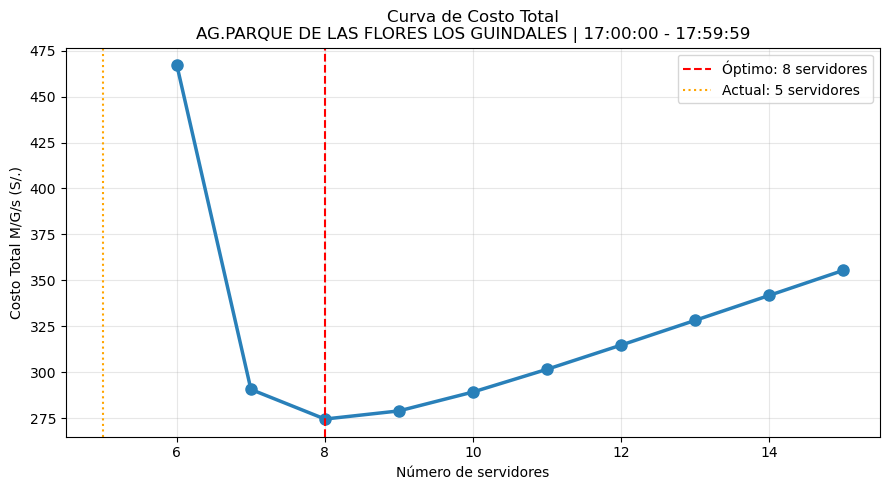

✅ Óptimo: 8 servidores | CT = S/. 274.44


In [ ]:
def servidores_optimos(lam, mu, Cs, Cq, C_s2, max_s=15):
    """Busca el s que minimiza CT via M/G/s. Retorna (s_opt, ct_opt, curva)."""
    r      = lam / mu if mu > 0 else np.inf
    best   = np.inf
    best_s = max(1, int(np.ceil(r)) + 1)
    curva  = []
    for s in range(1, max_s + 1):
        m  = mgs_metricas(lam, mu, s, Cs, Cq, C_s2)
        ct = m['CT_mg']
        if not np.isnan(ct):
            curva.append((s, ct))
            if ct < best:
                best, best_s = ct, s
    return best_s, best, curva

# Curva de costo para la hora más crítica (fila 8: 17:00)
fila = df2.iloc[8]
s_opt, ct_opt, curva = servidores_optimos(
    fila['lambda'],fila['mu'],fila['Cs'],fila['Cq'],fila['C_s2'])

s_vals  = [x[0] for x in curva]
ct_vals = [x[1] for x in curva]

plt.figure(figsize=(9,5))
plt.plot(s_vals, ct_vals, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
plt.axvline(s_opt, color='red', linestyle='--', linewidth=1.5, label=f'Óptimo: {s_opt} servidores')
plt.axvline(fila['servidores'], color='orange', linestyle=':', linewidth=1.5,
            label=f'Actual: {int(fila["servidores"])} servidores')
plt.xlabel('Número de servidores')
plt.ylabel('Costo Total M/G/s (S/.)')
plt.title(f'Curva de Costo Total\n{fila["agencia"][:45]} | {fila["hora"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_costo_optimo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Óptimo: {s_opt} servidores | CT = S/. {ct_opt:.2f}')

---
## PASO 9 — Aplicar modelo a todas las agencias y franjas horarias

In [ ]:
resultados = []

for _, row in df2.iterrows():
    lam, mu, c = row['lambda'], row['mu'], row['servidores']
    Cs, Cq, C_s2 = row['Cs'], row['Cq'], row['C_s2']
    
    m_actual            = mgs_metricas(lam, mu, c, Cs, Cq, C_s2)
    s_opt, ct_opt, _    = servidores_optimos(lam, mu, Cs, Cq, C_s2)
    m_opt               = mgs_metricas(lam, mu, s_opt, Cs, Cq, C_s2)
    
    diff = s_opt - c
    decision = f'CONTRATAR {diff}' if diff>0 else (f'REDUCIR {abs(diff)}' if diff<0 else 'MANTENER')
    ahorro   = (m_actual['CT_mg'] - ct_opt) if not np.isnan(m_actual['CT_mg']) else np.nan
    
    def r(v): return round(v,4) if not np.isnan(v) else np.nan
    def r2(v): return round(v,2) if not np.isnan(v) else np.nan
    
    rec = {
        'agencia': row['agencia'], 'hora': row['hora'],
        'lambda': round(lam,2), 'mu': r(mu), 'C_s2': r(C_s2),
        'Cs': Cs, 'Cq': Cq,
        'servidores_actuales': int(c), 'servidores_optimos': s_opt, 'decision': decision,
        # M/M/s
        'rho': r(m_actual['rho']), 'P0': r(m_actual['P0']),
        'Lq_mms': r(m_actual['Lq']), 'Wq_m_mms': r(m_actual['Wq_m']),
        'Ws_m_mms': r(m_actual['Ws_m']), 'Ls_mms': r(m_actual['Ls']),
        # M/G/s actual
        'Lq_mgs': r(m_actual['Lq_mg']), 'Wq_m_mgs': r(m_actual['Wq_m_mg']),
        'Ws_m_mgs': r(m_actual['Ws_m_mg']), 'Ls_mgs': r(m_actual['Ls_mg']),
        # Servidores
        'serv_ocupados': r(m_actual['serv_ocupados']),
        'serv_ociosos': r(m_actual['serv_ociosos']),
        # Costos
        'CTS': r2(m_actual['CTS']), 'CTS_idle': r2(m_actual['CTS_idle']),
        'CTQ_mgs': r2(m_actual['CTQ_mg']), 'CT_actual': r2(m_actual['CT_mg']),
        # Óptimo
        'CT_optimo': r2(ct_opt),
        'Wq_m_optimo': r2(m_opt['Wq_m_mg']),
        'ahorro_potencial': r2(ahorro),
        'contratar_auxiliar': 'SÍ' if s_opt>c else 'NO',
        'util_pct': round(m_actual['rho']*100,1) if not np.isnan(m_actual['rho']) else np.nan,
    }
    resultados.append(rec)

result_df = pd.DataFrame(resultados)

print('=== Resumen de decisiones ===')
print(result_df[['agencia','hora','servidores_actuales','servidores_optimos',
                  'CT_actual','CT_optimo','ahorro_potencial','decision']].to_string(index=False))

=== Resumen de decisiones ===
                              agencia                hora  servidores_actuales  servidores_optimos  CT_actual  CT_optimo  ahorro_potencial    decision
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59                    5                   6   200.4200   192.0800            8.3400 CONTRATAR 1
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59                    5                   7   414.3700   231.8200          182.5500 CONTRATAR 2
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59                    5                   7   387.8500   230.1400          157.7000 CONTRATAR 2
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59                    5                   6   185.1100   183.4100            1.6900 CONTRATAR 1
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59                    5                   5   149.6300   149.6300            0.0000    MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59       

---
## PASO 10 — Análisis de sensibilidad

¿Qué pasa con el costo y el óptimo si la demanda varía en ±20%?
Esto permite al gerente planificar para diferentes escenarios.

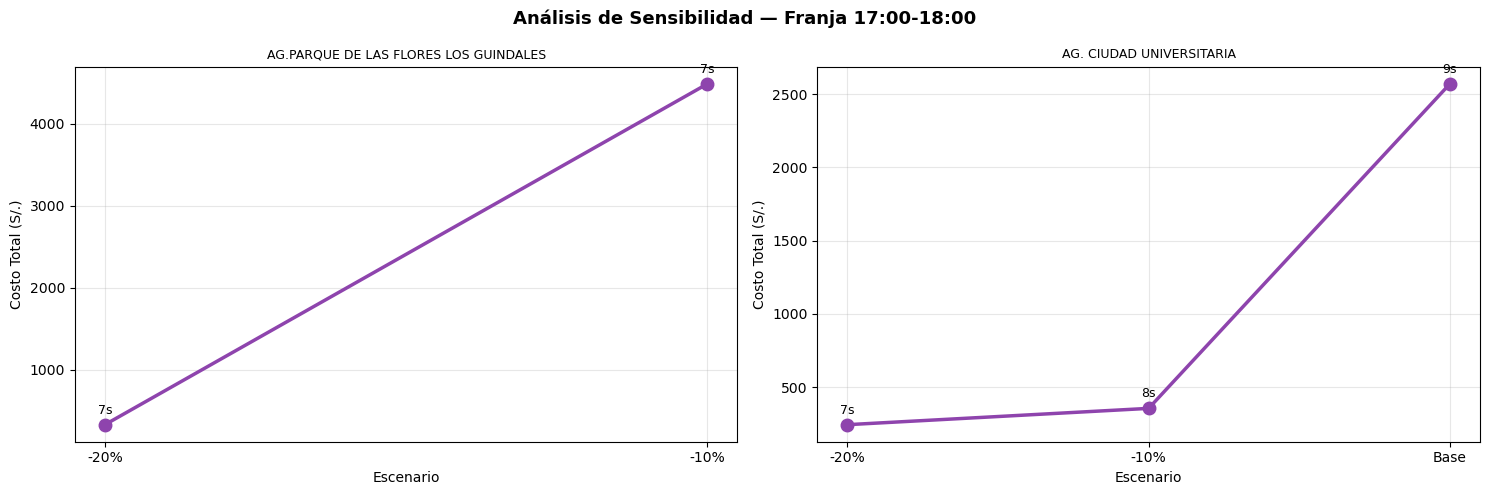

✅ Gráfico guardado: sensibilidad.png


In [ ]:
factores = [0.80, 0.90, 1.00, 1.10, 1.20]
labels   = ['-20%', '-10%', 'Base', '+10%', '+20%']

sens_rows = []
for _, row in df2.iterrows():
    for factor, label in zip(factores, labels):
        lam_var = row['lambda'] * factor
        m       = mgs_metricas(lam_var,row['mu'],row['servidores'],row['Cs'],row['Cq'],row['C_s2'])
        s_opt,ct_opt,_ = servidores_optimos(lam_var,row['mu'],row['Cs'],row['Cq'],row['C_s2'])
        sens_rows.append({
            'agencia': row['agencia'], 'hora': row['hora'], 'escenario': label,
            'lambda_var': round(lam_var,2),
            'CT_var': round(m['CT_mg'],2) if not np.isnan(m['CT_mg']) else np.nan,
            'Wq_m_var': round(m['Wq_m_mg'],2) if not np.isnan(m['Wq_m_mg']) else np.nan,
            's_opt_var': s_opt,
        })

sens_df = pd.DataFrame(sens_rows)

# Visualización para la hora pico 17:00
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle('Análisis de Sensibilidad — Franja 17:00-18:00', fontsize=13, fontweight='bold')

for ax, agencia in zip(axes, df2['agencia'].unique()):
    sub = sens_df[(sens_df['agencia']==agencia) & (sens_df['hora']=='17:00:00 - 17:59:59')]
    ax.plot(sub['escenario'], sub['CT_var'], 'o-', color='#8e44ad', linewidth=2.5, markersize=9)
    for _, r in sub.iterrows():
        ax.annotate(f"{r['s_opt_var']}s",(r['escenario'],r['CT_var']),
                    textcoords='offset points',xytext=(0,8),ha='center',fontsize=9)
    ax.set_title(agencia[:38],fontsize=9)
    ax.set_xlabel('Escenario')
    ax.set_ylabel('Costo Total (S/.)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sensibilidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: sensibilidad.png')

---
## PASO 11 — Exportar dataset final para Power BI

Generamos tres tablas:
1. **powerbi_principal.csv** → métricas completas por agencia-hora
2. **powerbi_sensibilidad.csv** → escenarios para análisis de sensibilidad
3. **powerbi_resumen_agencia.csv** → KPIs agregados por agencia

In [ ]:
# Tabla 1: Principal
result_df.to_csv('powerbi_principal.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_principal.csv      → {result_df.shape[0]} filas, {result_df.shape[1]} cols')

# Tabla 2: Sensibilidad
sens_df.to_csv('powerbi_sensibilidad.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_sensibilidad.csv   → {sens_df.shape[0]} filas')

# Tabla 3: Resumen por agencia
resumen = result_df.groupby('agencia').agg(
    horas_analizadas    = ('hora','count'),
    lambda_promedio     = ('lambda','mean'),
    mu_promedio         = ('mu','mean'),
    rho_promedio        = ('rho','mean'),
    serv_actuales_prom  = ('servidores_actuales','mean'),
    serv_optimos_prom   = ('servidores_optimos','mean'),
    Wq_m_promedio       = ('Wq_m_mgs','mean'),
    CT_actual_total     = ('CT_actual','sum'),
    CT_optimo_total     = ('CT_optimo','sum'),
    ahorro_total        = ('ahorro_potencial','sum'),
    horas_contratar     = ('contratar_auxiliar', lambda x: (x=='SÍ').sum())
).round(2).reset_index()

resumen['pct_ahorro'] = (resumen['ahorro_total'] / resumen['CT_actual_total'] * 100).round(1)
resumen.to_csv('powerbi_resumen_agencia.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_resumen_agencia.csv → {resumen.shape[0]} filas')
print()
print(resumen[['agencia','CT_actual_total','CT_optimo_total','ahorro_total','pct_ahorro','horas_contratar']].to_string(index=False))

✅ powerbi_principal.csv      → 20 filas, 31 cols
✅ powerbi_sensibilidad.csv   → 100 filas
✅ powerbi_resumen_agencia.csv → 2 filas

                              agencia  CT_actual_total  CT_optimo_total  ahorro_total  pct_ahorro  horas_contratar
             AG. CIUDAD UNIVERSITARIA        4320.1500        1915.1100     2405.0500     55.7000                4
AG.PARQUE DE LAS FLORES LOS GUINDALES        2172.8400        1934.8200      512.4400     23.6000                6


---
## PASO 12 — Visualizaciones finales (resumen ejecutivo)

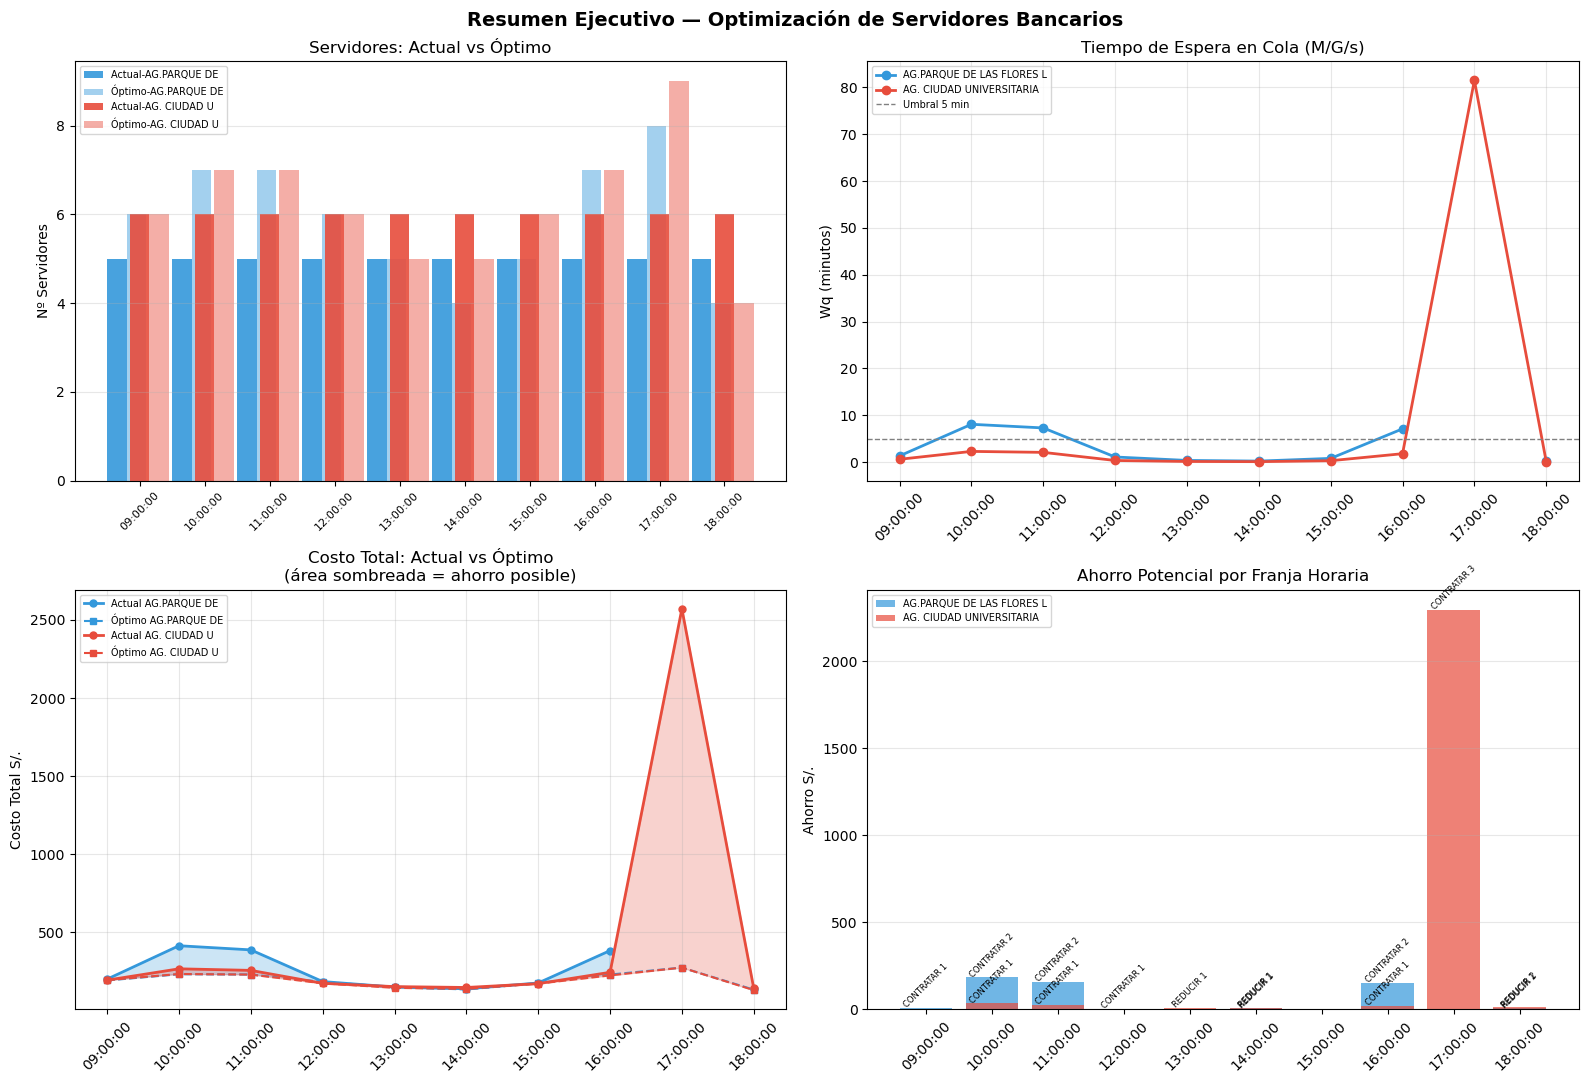

✅ Gráfico guardado: dashboard_resumen.png


In [ ]:
fig, axes = plt.subplots(2,2,figsize=(16,11))
fig.suptitle('Resumen Ejecutivo — Optimización de Servidores Bancarios',fontsize=14,fontweight='bold')

agencias = result_df['agencia'].unique()
colores2 = ['#3498db','#e74c3c']

# Plot 1: Servidores actuales vs óptimos
ax = axes[0,0]
for i,(agencia,col) in enumerate(zip(agencias,colores2)):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    x   = np.arange(len(hrs)) + i*0.35
    ax.bar(x,     sub['servidores_actuales'],width=0.3,color=col,alpha=0.9,label=f'Actual-{agencia[:12]}')
    ax.bar(x+0.3, sub['servidores_optimos'], width=0.3,color=col,alpha=0.45,label=f'Óptimo-{agencia[:12]}')
ax.set_xticks(np.arange(10)+0.35)
ax.set_xticklabels([h.split(' ')[0] for h in result_df[result_df['agencia']==agencias[0]]['hora']],rotation=45,fontsize=8)
ax.set_title('Servidores: Actual vs Óptimo')
ax.set_ylabel('Nº Servidores')
ax.legend(fontsize=7)
ax.grid(axis='y',alpha=0.3)

# Plot 2: Tiempo de espera
ax = axes[0,1]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    ax.plot(hrs,sub['Wq_m_mgs'],'o-',color=col,linewidth=2,label=agencia[:25],markersize=6)
ax.axhline(5,color='gray',linestyle='--',linewidth=1,label='Umbral 5 min')
ax.set_title('Tiempo de Espera en Cola (M/G/s)')
ax.set_ylabel('Wq (minutos)')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Plot 3: CT actual vs óptimo
ax = axes[1,0]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    ax.fill_between(hrs,sub['CT_actual'],sub['CT_optimo'],alpha=0.25,color=col)
    ax.plot(hrs,sub['CT_actual'],'o-',color=col,linewidth=2,markersize=5,label=f'Actual {agencia[:12]}')
    ax.plot(hrs,sub['CT_optimo'],'s--',color=col,linewidth=1.5,markersize=5,label=f'Óptimo {agencia[:12]}')
ax.set_title('Costo Total: Actual vs Óptimo\n(área sombreada = ahorro posible)')
ax.set_ylabel('Costo Total S/.')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Plot 4: Ahorro potencial
ax = axes[1,1]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    bars = ax.bar(hrs,sub['ahorro_potencial'],color=col,alpha=0.7,label=agencia[:25])
    for bar,dec in zip(bars,sub['decision']):
        if dec!='MANTENER':
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
                    dec,ha='center',fontsize=6,rotation=45)
ax.set_title('Ahorro Potencial por Franja Horaria')
ax.set_ylabel('Ahorro S/.')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_resumen.png',dpi=130,bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: dashboard_resumen.png')

---
## PASO 13 — Conclusiones e Informe Ejecutivo

In [ ]:
print('='*70)
print('   INFORME EJECUTIVO — OPTIMIZACIÓN DE SERVIDORES BANCARIOS')
print('='*70)

for _, row_res in resumen.iterrows():
    print(f"\n📍 AGENCIA: {row_res['agencia']}")
    print(f"   Costo Total Actual  : S/. {row_res['CT_actual_total']:.2f}/día")
    print(f"   Costo Total Óptimo  : S/. {row_res['CT_optimo_total']:.2f}/día")
    print(f"   Ahorro Potencial    : S/. {row_res['ahorro_total']:.2f}/día ({row_res['pct_ahorro']}%)")
    print(f"   Horas c/ auxiliar adicional recomendado: {int(row_res['horas_contratar'])} de 10")

print()
print('-'*70)
print('DETALLE DE DECISIONES:')
print('-'*70)
cols = ['agencia','hora','servidores_actuales','servidores_optimos',
        'Wq_m_mgs','CT_actual','ahorro_potencial','decision']
print(result_df[cols].to_string(index=False))
print()
print('NOTA METODOLÓGICA:')
print('C_s² < 1 en todos los casos → los tiempos de servicio son más regulares')
print('que un proceso exponencial puro → las colas reales son menores a M/M/s.')
print('El modelo M/G/s (Allen-Cunneen) es más preciso para este contexto bancario.')

   INFORME EJECUTIVO — OPTIMIZACIÓN DE SERVIDORES BANCARIOS

📍 AGENCIA: AG. CIUDAD UNIVERSITARIA
   Costo Total Actual  : S/. 4320.15/día
   Costo Total Óptimo  : S/. 1915.11/día
   Ahorro Potencial    : S/. 2405.05/día (55.7%)
   Horas c/ auxiliar adicional recomendado: 4 de 10

📍 AGENCIA: AG.PARQUE DE LAS FLORES LOS GUINDALES
   Costo Total Actual  : S/. 2172.84/día
   Costo Total Óptimo  : S/. 1934.82/día
   Ahorro Potencial    : S/. 512.44/día (23.6%)
   Horas c/ auxiliar adicional recomendado: 6 de 10

----------------------------------------------------------------------
DETALLE DE DECISIONES:
----------------------------------------------------------------------
                              agencia                hora  servidores_actuales  servidores_optimos  Wq_m_mgs  CT_actual  ahorro_potencial    decision
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59                    5                   6    1.3185   200.4200            8.3400 CONTRATAR 1
AG.PARQUE DE LAS FLORE

---
## 📊 Propuesta de Dashboard Power BI

### Tablas a importar:
| Archivo | Uso en Power BI |
|---------|----------------|
| `powerbi_principal.csv` | Tabla central (20 filas) con todas las métricas |
| `powerbi_sensibilidad.csv` | Tabla para análisis de escenarios (100 filas) |
| `powerbi_resumen_agencia.csv` | Tabla de KPIs por agencia (2 filas) |

### Páginas sugeridas:

**Página 1 — Decisión de Contratación (para gerencia)**
- Tarjetas KPI: Ahorro Total Potencial | Horas donde contratar | Costo actual vs óptimo
- Tabla con columna de semáforo: CONTRATAR / MANTENER / REDUCIR
- Filtros: Agencia | Hora

**Página 2 — Tiempos y Colas**
- Gráfico de líneas: Wq_m_mgs por hora (comparativo entre agencias)
- Gráfico de barras: servidores_ociosos vs servidores_ocupados apilados
- KPI: rho promedio (utilización)

**Página 3 — Costos Detallados**
- Gráfico apilado: CTS + CTS_idle + CTQ por hora
- Comparativo barras: CT_actual vs CT_optimo
- Tabla de ahorro_potencial por hora

**Página 4 — Análisis de Sensibilidad**
- Gráfico de líneas: CT_var por escenario (-20% a +20%)
- Segmentador de hora y agencia
- Anotaciones con s_opt_var

### Medidas DAX sugeridas:
```dax
Ahorro_Total = SUM(powerbi_principal[ahorro_potencial])
Utilizacion_Prom = AVERAGE(powerbi_principal[util_pct])
Horas_Contratar = COUNTROWS(FILTER(powerbi_principal, powerbi_principal[contratar_auxiliar] = "SÍ"))
CT_Actual_Total = SUM(powerbi_principal[CT_actual])
CT_Optimo_Total = SUM(powerbi_principal[CT_optimo])
Pct_Ahorro = DIVIDE([Ahorro_Total], [CT_Actual_Total], 0) * 100
```